## **Weather Prediction Using Regression Models**

![https://www.un.org/sites/un2.un.org/files/styles/large-article-image-style-16-9/public/field/image/2023/03/52196025795_06f077377a_c.jpg](https://www.un.org/sites/un2.un.org/files/styles/large-article-image-style-16-9/public/field/image/2023/03/52196025795_06f077377a_c.jpg)


> Source: https://www.un.org/en/un-chronicle/future-weather-climate-and-water-across-generations

### **Regression algorithm in machine learning**

Regression analysis is a statistical technique for modeling the relationship between a dependent (target) variable and one or more independent (predictor) variables. More specifically, regression analysis helps us understand how the value of the dependent variable changes with respect to an independent variable when the other independent variables are held fixed. It predicts continuous/real values such as temperature, age, salary, price, etc.

There are different types of regressions used in data science and machine learning. Each type has its own importance in different scenarios, but at its core, all regression methods analyze the effect of the independent variable on the dependent variables.


![https://miro.medium.com/max/1400/1*-fniNC8gWI34qLAiBzgGZA.png](https://miro.medium.com/max/1400/1*-fniNC8gWI34qLAiBzgGZA.png)

> Source: https://www.javatpoint.com/regression-analysis-in-machine-learning

## **Let's start!**

In [1]:
# Import the necessary libraries
import seaborn as sns; sns.set()
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

In [2]:
# Set color scheme
color_1 = '#BFAF9D'
color_2 = '#C1C1D5'
color_3 = '#A16F86'
color_4 = sns.diverging_palette(h_neg = 32, h_pos = 32, s = 21, l = 68, as_cmap = True)

---
### **Data loading and initial review**

In [3]:
# Loading the data
df = pd.read_csv('../datasets/weather.csv') # https://www.kaggle.com/datasets/swatikhedekar/python-project-on-weather-dataset

In [4]:
# Dataset array dimension
df.shape

(8784, 8)

In [5]:
# Basic information about the data set
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 8784 entries, 0 to 8783
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Date/Time         8784 non-null   str    
 1   Temp_C            8784 non-null   float64
 2   Dew Point Temp_C  8784 non-null   float64
 3   Rel Hum_%         8784 non-null   int64  
 4   Wind Speed_km/h   8784 non-null   int64  
 5   Visibility_km     8784 non-null   float64
 6   Press_kPa         8784 non-null   float64
 7   Weather           8784 non-null   str    
dtypes: float64(4), int64(2), str(2)
memory usage: 549.1 KB


In [6]:
# The first five rows of the data set
df.head()

,Date/Time,Temp_C,Dew Point Temp_C,Rel Hum_%,Wind Speed_km/h,Visibility_km,Press_kPa,Weather
0,1/1/2012 0:00,-1.8,-3.9,86,4,8.0,101.24,Fog
1,1/1/2012 1:00,-1.8,-3.7,87,4,8.0,101.24,Fog
2,1/1/2012 2:00,-1.8,-3.4,89,7,4.0,101.26,"Freezing Drizzle,Fog"
3,1/1/2012 3:00,-1.5,-3.2,88,6,4.0,101.27,"Freezing Drizzle,Fog"
4,1/1/2012 4:00,-1.5,-3.3,88,7,4.8,101.23,Fog


In [7]:
# The last five rows of the data set
df.tail()

,Date/Time,Temp_C,Dew Point Temp_C,Rel Hum_%,Wind Speed_km/h,Visibility_km,Press_kPa,Weather
8779,12/31/2012 19:00,0.1,-2.7,81,30,9.7,100.13,Snow
8780,12/31/2012 20:00,0.2,-2.4,83,24,9.7,100.03,Snow
8781,12/31/2012 21:00,-0.5,-1.5,93,28,4.8,99.95,Snow
8782,12/31/2012 22:00,-0.2,-1.8,89,28,9.7,99.91,Snow
8783,12/31/2012 23:00,0.0,-2.1,86,30,11.3,99.89,Snow


---
### **Data reorganization and cleansing**

In [8]:
# Rename columns
df.columns = ['Datetime', 'Temp [C]', 'Dew Point Temp [C]', 'Rel Hum [%]', 'Wind Speed [km/h]', 'Visibility [km]', 'Press [kPa]', 'Weather']

# Convert time stamp column to time format
df.index = pd.to_datetime(df['Datetime']).dt.floor('min')
df = df.iloc[:, 1:]

# Separate 'Weather' column into three separate parts (each description of weather conditions in a separate column)
weather_column_split = ['Weather - p. 1', 'Weather - p. 2', 'Weather - p. 3']
df[weather_column_split] = df['Weather'].str.split(',', expand = True)

# Remove 'Weather' column (redundant)
df.drop(['Weather'], axis = 1, inplace = True)

# Storage of data on weather conditions according to zero-one coding.
weather_category_list = df[weather_column_split].stack().unique().dropna().tolist()
df[weather_category_list] = 0

for column in df[weather_column_split]:
    for index in df.index:
        if pd.notna(df.loc[index, column]):
            df.loc[index, df.loc[index, column]] = 1

# Delete 'Weather - p. 1', 'Weather - p. 2' and 'Weather - p. 3' columns (redundant)
df.drop(weather_column_split, axis = 1, inplace = True)

# Create an auxiliary set of column names in measured values
weather_measurement_data = ['Temp [C]', 'Dew Point Temp [C]', 'Rel Hum [%]', 'Wind Speed [km/h]', 'Visibility [km]', 'Press [kPa]']

In [9]:
# Display the dataset in tabular form (data after correction and formatting) - first records
df.head()

,Temp [C],Dew Point Temp [C],Rel Hum [%],Wind Speed [km/h],Visibility [km],Press [kPa],Fog,Freezing Drizzle,Mostly Cloudy,Cloudy,...,Blowing Snow,Freezing Fog,Haze,Drizzle,Ice Pellets,Thunderstorms,Heavy Rain Showers,Moderate Rain Showers,Snow Pellets,Moderate Rain
Datetime,,,,,,,,,,,,,,,,,,,,,
2012-01-01 00:00:00,-1.8,-3.9,86,4,8.0,101.24,1,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2012-01-01 01:00:00,-1.8,-3.7,87,4,8.0,101.24,1,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2012-01-01 02:00:00,-1.8,-3.4,89,7,4.0,101.26,1,1,0,0,...,0,0,0,0,0,0,0,0,0,0
2012-01-01 03:00:00,-1.5,-3.2,88,6,4.0,101.27,1,1,0,0,...,0,0,0,0,0,0,0,0,0,0
2012-01-01 04:00:00,-1.5,-3.3,88,7,4.8,101.23,1,0,0,0,...,0,0,0,0,0,0,0,0,0,0


The last column, which contained information on recorded weather phenomena, was separated and coded in the 0-1 system (dummy variables)

In [10]:
# Display of data frame information (data after correction and formatting)
df.info()

<class 'pandas.DataFrame'>
DatetimeIndex: 8784 entries, 2012-01-01 00:00:00 to 2012-12-31 23:00:00
Data columns (total 29 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Temp [C]               8784 non-null   float64
 1   Dew Point Temp [C]     8784 non-null   float64
 2   Rel Hum [%]            8784 non-null   int64  
 3   Wind Speed [km/h]      8784 non-null   int64  
 4   Visibility [km]        8784 non-null   float64
 5   Press [kPa]            8784 non-null   float64
 6   Fog                    8784 non-null   int64  
 7   Freezing Drizzle       8784 non-null   int64  
 8   Mostly Cloudy          8784 non-null   int64  
 9   Cloudy                 8784 non-null   int64  
 10  Rain                   8784 non-null   int64  
 11  Rain Showers           8784 non-null   int64  
 12  Mainly Clear           8784 non-null   int64  
 13  Snow Showers           8784 non-null   int64  
 14  Snow                   8784 non

In [11]:
# Display a statistical summary for selected columns
df[weather_measurement_data].describe()

,Temp [C],Dew Point Temp [C],Rel Hum [%],Wind Speed [km/h],Visibility [km],Press [kPa]
count,8784.000000,8784.000000,8784.000000,8784.000000,8784.000000,8784.000000
mean,8.798144,2.555294,67.431694,14.945469,27.664447,101.051623
std,11.687883,10.883072,16.918881,8.688696,12.622688,0.844005
min,-23.300000,-28.500000,18.000000,0.000000,0.200000,97.520000
25%,0.100000,-5.900000,56.000000,9.000000,24.100000,100.560000
50%,9.300000,3.300000,68.000000,13.000000,25.000000,101.070000
75%,18.800000,11.800000,81.000000,20.000000,25.000000,101.590000
max,33.000000,24.400000,100.000000,83.000000,48.300000,103.650000


---
### **Basic data visualization**

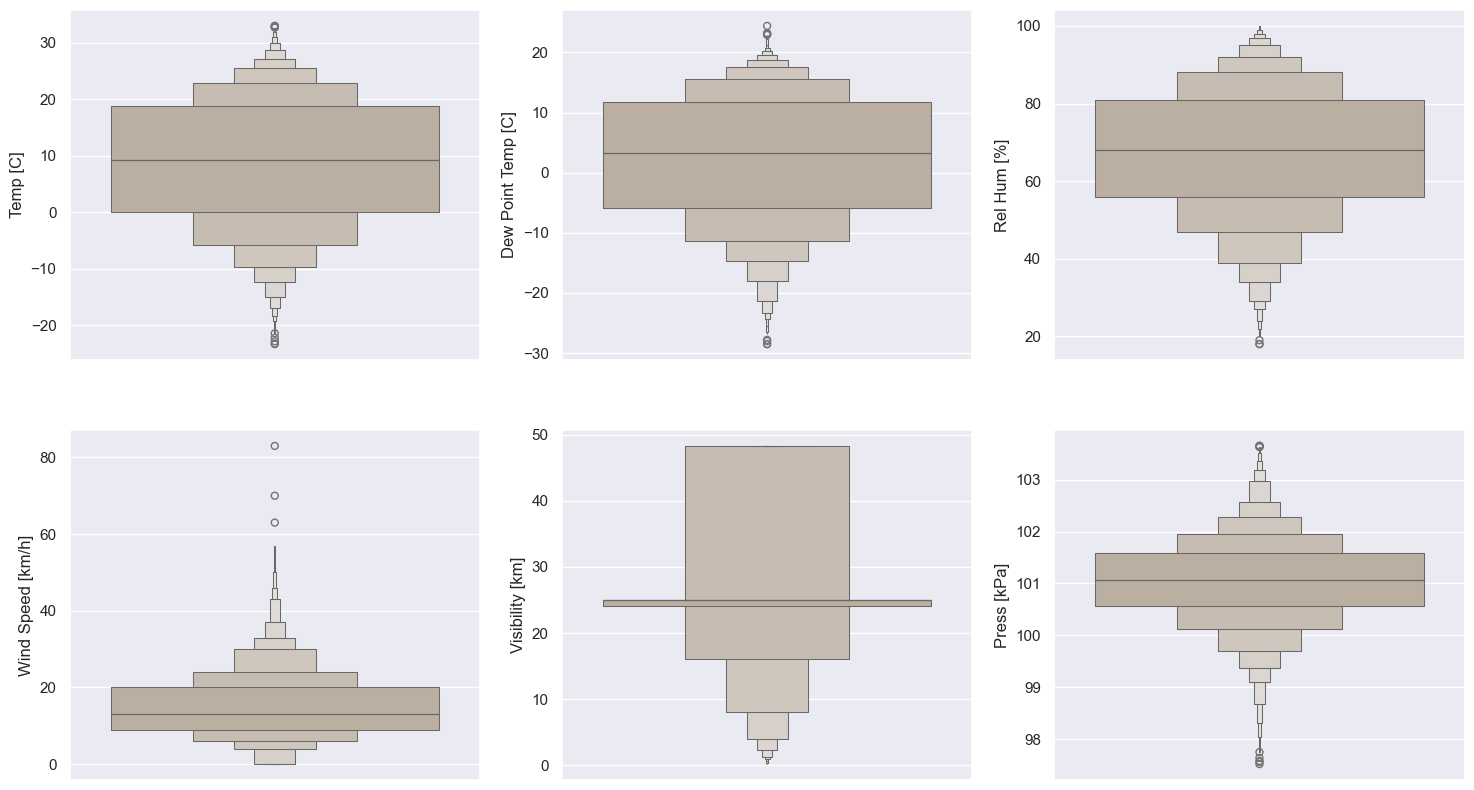

In [12]:
# Display of box charts
plt.figure(figsize = (18, 10))

plt.subplot(231)
sns.boxenplot(data = df, y = 'Temp [C]', color = color_1)

plt.subplot(232)
sns.boxenplot(data = df, y = 'Dew Point Temp [C]', color = color_1)

plt.subplot(233)
sns.boxenplot(data = df, y = 'Rel Hum [%]', color = color_1)

plt.subplot(234)
sns.boxenplot(data = df, y = 'Wind Speed [km/h]', color = color_1)

plt.subplot(235)
sns.boxenplot(data = df, y = 'Visibility [km]', color = color_1)

plt.subplot(236)
sns.boxenplot(data = df, y = 'Press [kPa]', color = color_1)

plt.show()

In [13]:
# Calculation of moving averages of individual measurement parameters
for column in df[weather_measurement_data]:
    df['SMA168 ' + column] = df[column].rolling('168h', center = True).mean()

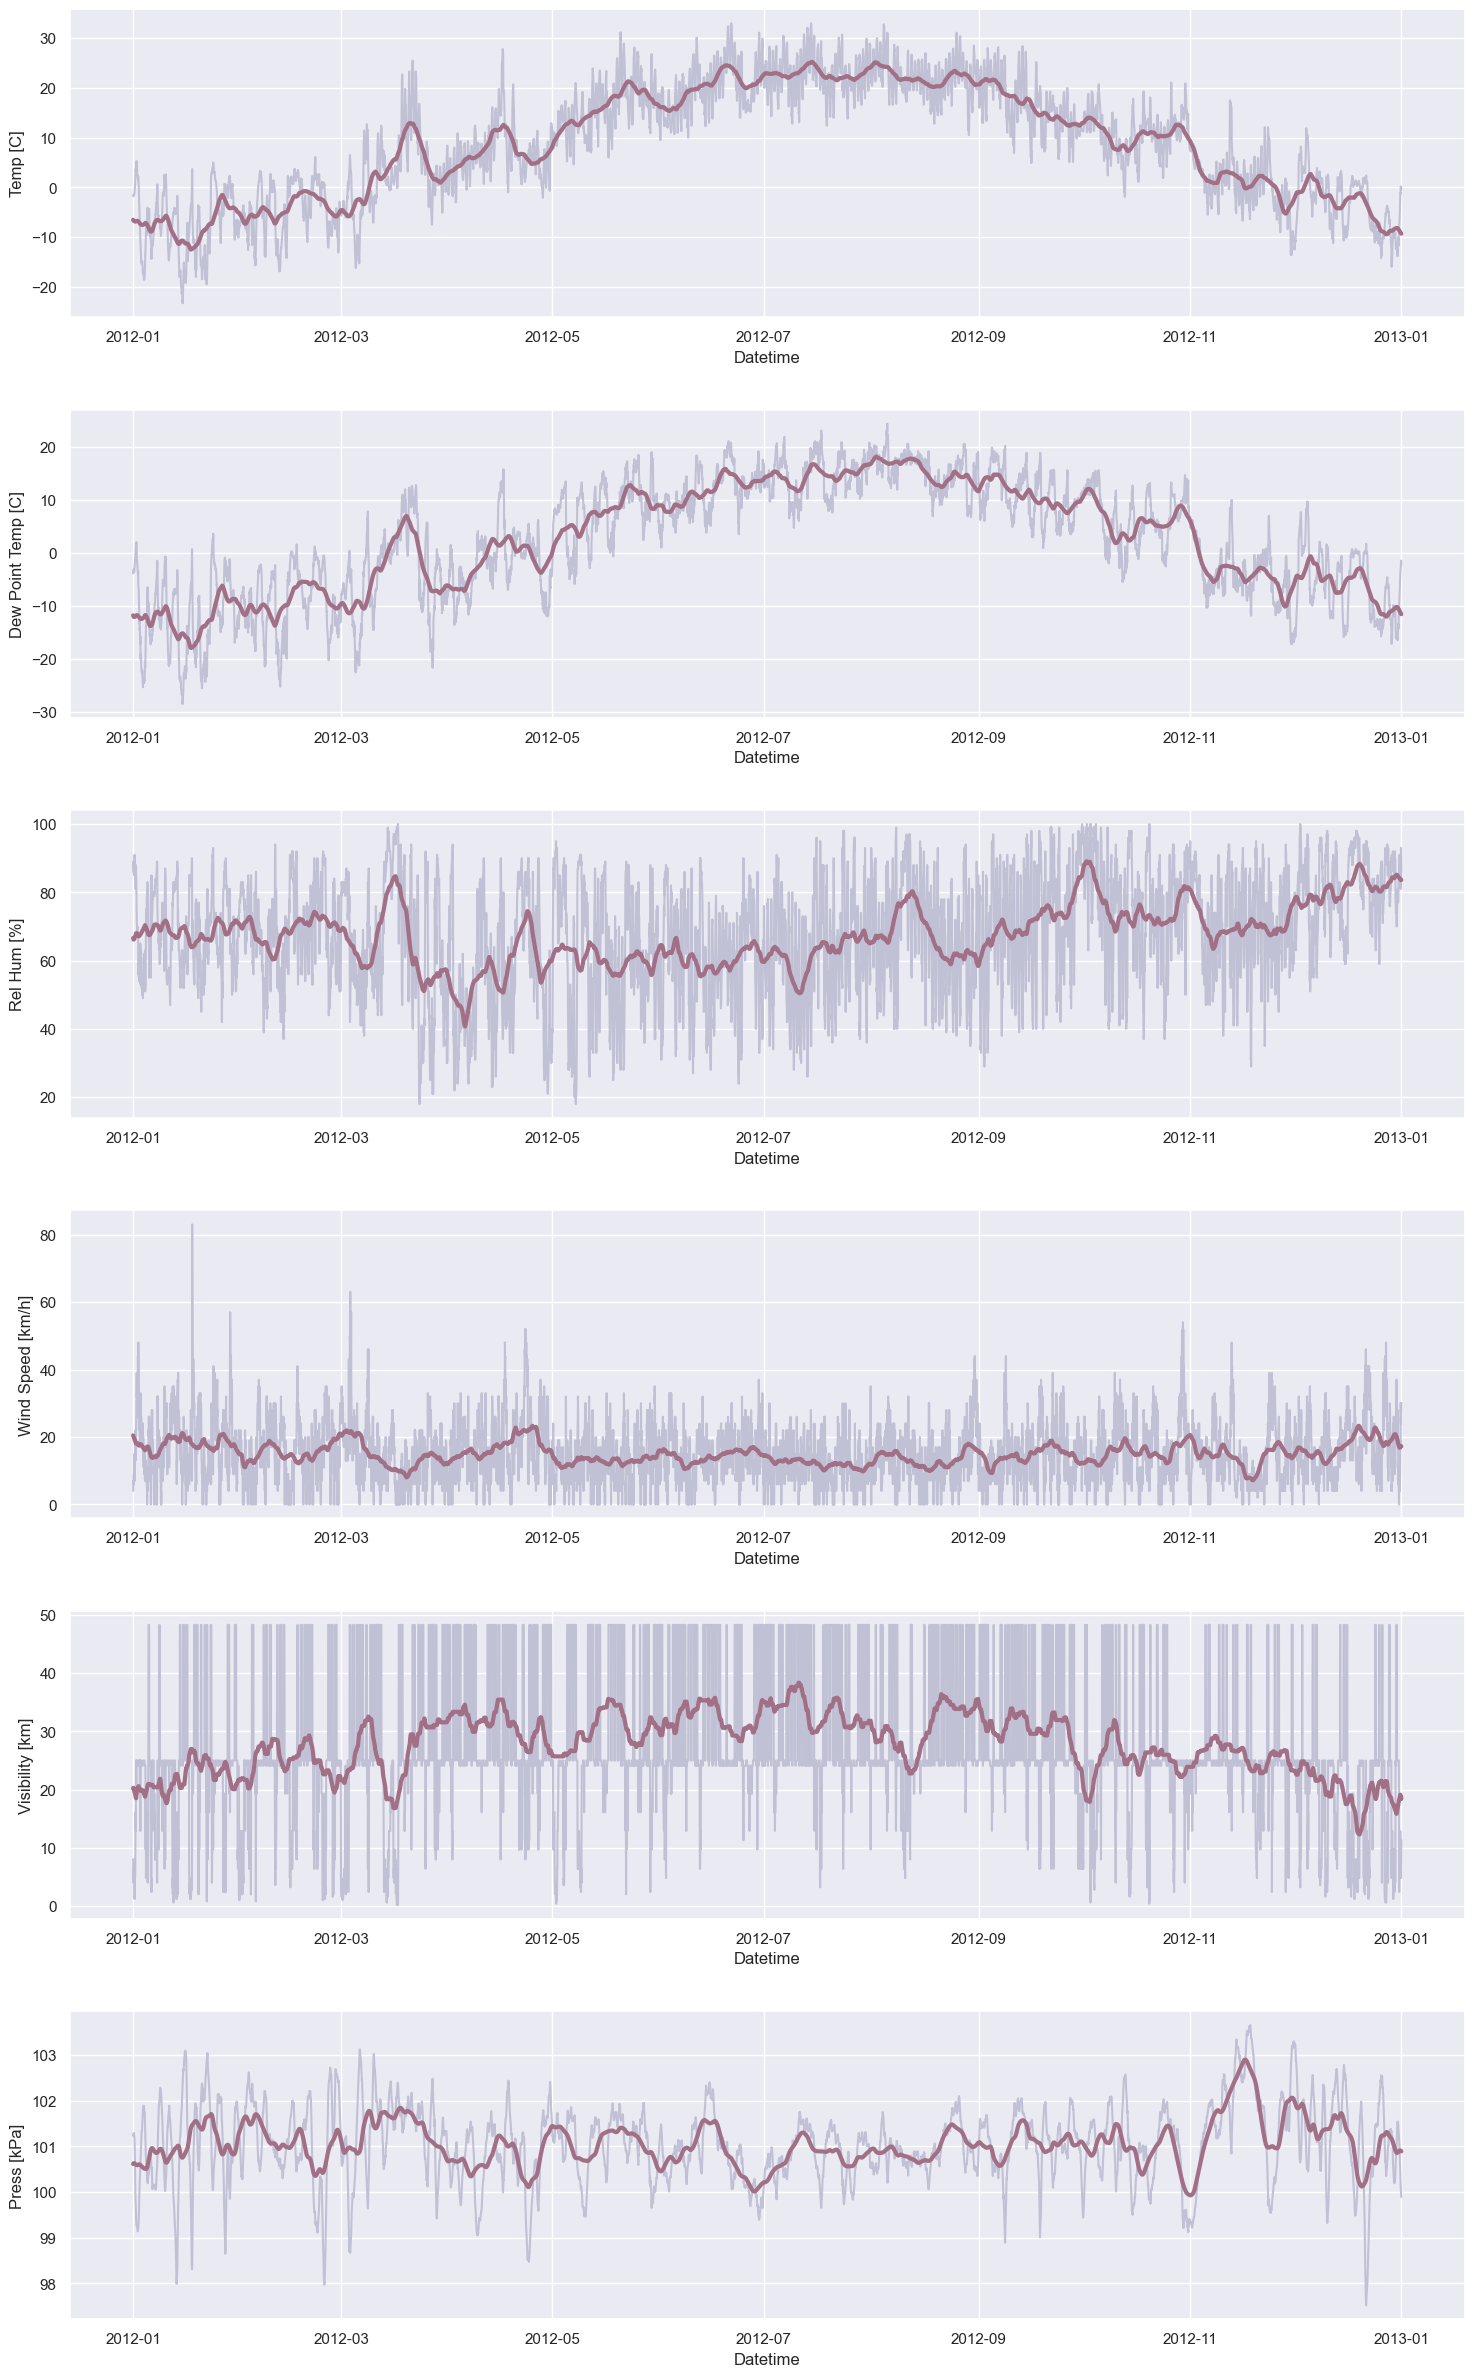

In [14]:
# Display line graphs
plt.figure(figsize = (18, 30))

plt.subplot(611)
sns.lineplot(data = df, x = 'Datetime', y = 'Temp [C]', color = color_2)
sns.lineplot(data = df, x = 'Datetime', y = 'SMA168 Temp [C]', color = color_3, lw = 3)

plt.subplot(612)
sns.lineplot(data = df, x = 'Datetime', y = 'Dew Point Temp [C]', color = color_2)
sns.lineplot(data = df, x = 'Datetime', y = 'SMA168 Dew Point Temp [C]', color = color_3, lw = 3)

plt.subplot(613)
sns.lineplot(data = df, x = 'Datetime', y = 'Rel Hum [%]', color = color_2)
sns.lineplot(data = df, x = 'Datetime', y = 'SMA168 Rel Hum [%]', color = color_3, lw = 3)

plt.subplot(614)
sns.lineplot(data = df, x = 'Datetime', y = 'Wind Speed [km/h]', color = color_2)
sns.lineplot(data = df, x = 'Datetime', y = 'SMA168 Wind Speed [km/h]', color = color_3, lw = 3)

plt.subplot(615)
sns.lineplot(data = df, x = 'Datetime', y = 'Visibility [km]', color = color_2)
sns.lineplot(data = df, x = 'Datetime', y = 'SMA168 Visibility [km]', color = color_3, lw = 3)

plt.subplot(616)
sns.lineplot(data = df, x = 'Datetime', y = 'Press [kPa]', color = color_2)
sns.lineplot(data = df, x = 'Datetime', y = 'SMA168 Press [kPa]', color = color_3, lw = 3)

plt.subplots_adjust(hspace = 0.3)
plt.show()

---
### **Regression algorithms**

The following is an example of using machine learning algorithms to predict visibility based on other collected measurement data such as temperature, humidity, air pressure, time of day, or precipitation occurrence information.

The data used by the machine learning algorithms has been properly prepared, i.e. it has been scaled using the StandardScaler class from the *scikit-learn* module.

> Take a look: http://scikit-learn.org/stable/modules/preprocessing.html

In [15]:
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

In [16]:
df['Datetime (month)'] = pd.to_datetime(df.index).month
df['Datetime (day)'] = pd.to_datetime(df.index).day
df['Datetime (hour)'] = pd.to_datetime(df.index).hour

param_ml_input = ['Datetime (month)', 'Datetime (day)', 'Datetime (hour)', 'Temp [C]', 'Rel Hum [%]', 'Press [kPa]', 'Fog', 'Rain', 'Snow']
param_ml_output = 'Visibility [km]'

In [17]:
X_data = df[param_ml_input]
y_data = df[param_ml_output]

X_train, X_test, y_train, y_test = train_test_split(X_data, y_data, test_size = 1/3)

In [18]:
scaler =  StandardScaler()
scaler.fit(X_train)

X_train_scaled = scaler.transform(X_train)
X_test_scaled = scaler.transform(X_test)

#### **Neural Network**
Machine Learning > Supervised Learning > Regression > Neural Network

> Take a look: http://scikit-learn.org/stable/modules/neural_networks_supervised.html

In [19]:
from sklearn.neural_network import MLPRegressor

In [20]:
mlp = MLPRegressor(max_iter = 5000).fit(X_train_scaled, y_train)
y_pred = mlp.predict(X_test_scaled)

In [21]:
result = pd.DataFrame({'Actual value (y_test)': y_test,
                       'Value predicted by the model (y_pred)': y_pred,
                       'Difference': abs(y_pred - y_test)})
result.head()

,Actual value (y_test),Value predicted by the model (y_pred),Difference
Datetime,,,
2012-08-26 00:00:00,25.0,22.888486,2.111514
2012-01-18 00:00:00,8.0,6.765281,1.234719
2012-02-26 21:00:00,25.0,24.484365,0.515635
2012-11-27 21:00:00,25.0,24.721426,0.278574
2012-09-09 06:00:00,24.1,26.263861,2.163861


In [22]:
result.describe()[result.describe().index != 'count']

,Actual value (y_test),Value predicted by the model (y_pred),Difference
mean,27.798463,27.542538,5.309701
std,12.779060,10.130010,5.174368
min,0.200000,-1.759027,0.000784
25%,24.100000,22.823819,1.464749
50%,25.000000,26.333806,3.469966
75%,25.000000,33.044218,7.411102
max,48.300000,54.697483,31.283305


#### **Random Forest**
Machine Learning > Supervised Learning > Regression > Random Forest

> Take a look: http://scikit-learn.org/stable/modules/generated/sklearn.ensemble.RandomForestRegressor.html

In [23]:
from sklearn.ensemble import RandomForestRegressor

In [24]:
rfr = RandomForestRegressor().fit(X_train_scaled, y_train)
y_pred = rfr.predict(X_test_scaled)

In [25]:
result = pd.DataFrame({'Actual value (y_test)': y_test,
                       'Value predicted by the model (y_pred)': y_pred,
                       'Difference': abs(y_pred - y_test)})
result.head()

,Actual value (y_test),Value predicted by the model (y_pred),Difference
Datetime,,,
2012-08-26 00:00:00,25.0,25.000,0.000
2012-01-18 00:00:00,8.0,7.029,0.971
2012-02-26 21:00:00,25.0,25.000,0.000
2012-11-27 21:00:00,25.0,24.715,0.285
2012-09-09 06:00:00,24.1,23.656,0.444


In [26]:
result.describe()[result.describe().index != 'count']

,Actual value (y_test),Value predicted by the model (y_pred),Difference
mean,27.798463,27.763775,3.938954
std,12.779060,10.647295,5.197016
min,0.200000,0.974000,0.000000
25%,24.100000,24.220500,0.233000
50%,25.000000,25.224000,1.735500
75%,25.000000,33.316250,5.517500
max,48.300000,48.300000,31.927000
